# 🚀 Startup Signal Intelligence
## Análise de Linguagem Natural sobre Repositórios GitHub e Startups Brasileiras

**Projeto — Etapas 1, 2 e 3**

Este projeto aplica PLN (Processamento de Linguagem Natural) para analisar textos de repositórios de software e dados de startups, combinando:
- **Etapa 1**: Expressões regulares (`re`) + spaCy (tokenização, lematização)
- **Etapa 2**: Coleta via Web API (GitHub + BrasilAPI) + BeautifulSoup
- **Etapa 3**: spaCy completo (POS, NER, noun chunks, sentenças) + Classificação + Sentimentos com Transformers + Gráficos

**Base científica**: Qiu et al. (2025), Peixoto et al. (2023), Saura et al. (2019), Jin et al. (2017)

---
# ⚙️ INSTALAÇÃO E CONFIGURAÇÃO

In [6]:
# Instalação de dependências
!pip install -U spacy -q
!python -m spacy download pt_core_news_sm -q
!pip install sentence-transformers -q
!pip install transformers torch -q
!pip install plotly -q
!pip install wordcloud -q
!pip install beautifulsoup4 requests -q
print('✅ Instalação concluída!')

✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
✅ Instalação concluída!


In [8]:
# Importações gerais
import re
import spacy
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import random
import string
from bs4 import BeautifulSoup
from spacy import displacy
from spacy.training import Example
from spacy.lang.pt.stop_words import STOP_WORDS
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from IPython.display import display, HTML
from collections import Counter

# Carregar modelo spaCy em português
nlp = spacy.load('pt_core_news_sm')
print('✅ Todas as bibliotecas carregadas!')

✅ Todas as bibliotecas carregadas!


---
# 📌 ETAPA 1 — Expressões Regulares (RE) + spaCy

## 1.1 — Módulo `re`: Limpeza e extração de padrões textuais
Usamos regex para **pré-processar** textos brutos antes de enviá-los ao spaCy, exatamente como ensinado na Aula 2.

In [10]:
# ============================================================
# ETAPA 1 — EXPRESSÕES REGULARES (módulo re)
# ============================================================

# Texto simulando um README bruto de uma startup
readme_bruto = """
# 🚀 FinTech API v2.3.1

[![Build](https://img.shields.io/badge/build-passing-green)]
Contato: contato@fintechstartup.com.br | suporte@fintechstartup.io
CPFs de teste: 123.456.789-09 e 987.654.321-00

## Instalação
```bash
pip install fintech-api
```

Veja mais em https://docs.fintechstartup.com.br/v2
Versões anteriores: v1.0, v1.2, v2.0 foram descontinuadas.
Issues relacionadas: #142, #87, #201
Time: @alice @bob @carol contribuíram nesta versão.
"""

print('=== TEXTO BRUTO ===')
print(readme_bruto[:200], '...')
print()

# 1. re.sub() — remover blocos de código markdown
texto = re.sub(r'```[\s\S]*?```', '', readme_bruto)

# 2. re.sub() — remover URLs
texto = re.sub(r'https?://\S+', '[URL]', texto)

# 3. re.sub() — remover badges/imagens markdown
texto = re.sub(r'!\[.*?\]\(.*?\)', '', texto)

# 4. re.sub() — remover headers markdown
texto = re.sub(r'#+\s', '', texto)

print('=== TEXTO LIMPO (após re.sub) ===')
print(texto.strip())
print()

=== TEXTO BRUTO ===

# 🚀 FinTech API v2.3.1

[![Build](https://img.shields.io/badge/build-passing-green)]
Contato: contato@fintechstartup.com.br | suporte@fintechstartup.io
CPFs de teste: 123.456.789-09 e 987.654.321-00
 ...

=== TEXTO LIMPO (após re.sub) ===
🚀 FinTech API v2.3.1

[![Build]([URL]
Contato: contato@fintechstartup.com.br | suporte@fintechstartup.io
CPFs de teste: 123.456.789-09 e 987.654.321-00

Instalação


Veja mais em [URL]
Versões anteriores: v1.0, v1.2, v2.0 foram descontinuadas.
Issues relacionadas: #142, #87, #201
Time: @alice @bob @carol contribuíram nesta versão.



In [11]:
# re.findall() — extrair padrões específicos do texto

# Extrair e-mails
emails = re.findall(r'\b[\w.-]+@[\w.-]+\.\w+\b', readme_bruto)
print(f'📧 E-mails encontrados: {emails}')

# Extrair CPFs
cpfs = re.findall(r'\d{3}\.\d{3}\.\d{3}-\d{2}', readme_bruto)
print(f'🪪 CPFs encontrados: {cpfs}')

# Extrair versões de software (v1.0, v2.3.1 etc.)
versoes = re.findall(r'v?\d+\.\d+\.?\d*', readme_bruto)
print(f'📦 Versões encontradas: {versoes}')

# Extrair mentions (@usuario)
mentions = re.findall(r'@[\w-]+', readme_bruto)
print(f'👤 Mentions encontrados: {mentions}')

# Extrair referências a issues (#123)
issue_refs = re.findall(r'#\d+', readme_bruto)
print(f'🔗 Issues referenciadas: {issue_refs}')

📧 E-mails encontrados: ['contato@fintechstartup.com.br', 'suporte@fintechstartup.io']
🪪 CPFs encontrados: ['123.456.789-09', '987.654.321-00']
📦 Versões encontradas: ['v2.3.1', '123.456.789', '987.654.321', 'v1.0', 'v1.2', 'v2.0']
👤 Mentions encontrados: ['@fintechstartup', '@fintechstartup', '@alice', '@bob', '@carol']
🔗 Issues referenciadas: ['#142', '#87', '#201']


In [12]:
# re.search() — verificar qualidade do README (indicadores de boa documentação)

indicadores = {
    'Badge de CI/Build': bool(re.search(r'!\[.*?(build|ci|test).*?\]', readme_bruto, re.IGNORECASE)),
    'Seção de Instalação': bool(re.search(r'##\s*(install|instalação|setup)', readme_bruto, re.IGNORECASE)),
    'Link de documentação': bool(re.search(r'https?://docs\.', readme_bruto, re.IGNORECASE)),
    'Contato/E-mail': bool(re.search(r'[\w.-]+@[\w.-]+\.\w+', readme_bruto)),
    'Referências a versões': bool(re.search(r'v\d+\.\d+', readme_bruto)),
}

print('📋 Análise de qualidade do README:')
for indicador, presente in indicadores.items():
    status = '✅' if presente else '❌'
    print(f'  {status} {indicador}')

score = sum(indicadores.values()) / len(indicadores) * 100
print(f'\n📊 Score de documentação: {score:.0f}%')

📋 Análise de qualidade do README:
  ✅ Badge de CI/Build
  ✅ Seção de Instalação
  ✅ Link de documentação
  ✅ Contato/E-mail
  ✅ Referências a versões

📊 Score de documentação: 100%


In [13]:
# re.split() — dividir changelog por versão para análise temporal

changelog = """
v2.3.1 - Correção de bug no módulo de autenticação. Melhoria de performance.
v2.0.0 - Nova arquitetura de microserviços. Integração com Pix.
v1.2.0 - Adicionado suporte a múltiplas moedas.
v1.0.0 - Lançamento inicial da API.
"""

# Dividir por versão
partes = re.split(r'(v\d+\.\d+\.?\d*)', changelog.strip())
versoes_changelog = [(partes[i], partes[i+1].strip()) for i in range(1, len(partes)-1, 2)]

print('📅 Changelog por versão:')
for versao, descricao in versoes_changelog:
    print(f'  {versao}: {descricao[:60]}...')

📅 Changelog por versão:
  v2.3.1: - Correção de bug no módulo de autenticação. Melhoria de per...
  v2.0.0: - Nova arquitetura de microserviços. Integração com Pix....
  v1.2.0: - Adicionado suporte a múltiplas moedas....
  v1.0.0: - Lançamento inicial da API....


## 1.2 — Pipeline combinada: RE + spaCy
Conforme Aula 2: primeiro limpamos com regex, depois analisamos linguisticamente com spaCy.

In [14]:
# Pipeline combinada: re.sub() → spaCy
# Exatamente como ensinado na Aula 2

textos_issues = [
    "O sistema de pagamento via Pix está falhando desde a versão v2.1.0. Contate suporte@empresa.com",
    "Ótima funcionalidade! O módulo de relatórios melhorou muito. Parabéns ao time @alice @bob",
    "Bug crítico no endpoint https://api.empresa.com/v2/auth. Issue #342 relacionada.",
    "A documentação está desatualizada. Precisa urgente de revisão na seção de instalação.",
    "Incrível! A performance melhorou 40% após o último release. Excelente trabalho!",
]

def limpar_com_regex(texto):
    """Pré-processamento com regex antes do spaCy."""
    texto = re.sub(r'https?://\S+', '', texto)           # Remove URLs
    texto = re.sub(r'@[\w-]+', '', texto)                 # Remove mentions
    texto = re.sub(r'#\d+', '', texto)                    # Remove refs a issues
    texto = re.sub(r'[\w.-]+@[\w.-]+\.\w+', '', texto)   # Remove e-mails
    texto = re.sub(r'v\d+\.\d+\.?\d*', '', texto)        # Remove versões
    texto = re.sub(r'\s+', ' ', texto).strip()            # Normaliza espaços
    return texto

print('=== PIPELINE RE + spaCy ===\n')
for i, issue in enumerate(textos_issues, 1):
    limpo = limpar_com_regex(issue)
    doc = nlp(limpo)
    tokens_norm = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space and len(token.text) > 2
    ]
    print(f'Issue {i}: {issue[:60]}...')
    print(f'  Tokens normalizados: {tokens_norm[:8]}')
    print()

=== PIPELINE RE + spaCy ===

Issue 1: O sistema de pagamento via Pix está falhando desde a versão ...
  Tokens normalizados: ['pagamento', 'ver', 'pix', 'falhar', 'versão', 'contate', 'suporte.com']

Issue 2: Ótima funcionalidade! O módulo de relatórios melhorou muito....
  Tokens normalizados: ['ótima', 'funcionalidade', 'módulo', 'relatório', 'melhorar', 'parabéns', 'time']

Issue 3: Bug crítico no endpoint https://api.empresa.com/v2/auth. Iss...
  Tokens normalizados: ['bug', 'crítico', 'endpoint', 'issue', 'relacionado']

Issue 4: A documentação está desatualizada. Precisa urgente de revisã...
  Tokens normalizados: ['documentação', 'desatualizado', 'precisa', 'urgente', 'revisão', 'seção', 'instalação']

Issue 5: Incrível! A performance melhorou 40% após o último release. ...
  Tokens normalizados: ['incrível', 'performance', 'melhorar', 'release', 'excelente', 'trabalho']



---
# 🌐 ETAPA 2 — Web Scraping + Coleta via APIs

## 2.1 — API do GitHub (requests)

In [18]:
# ============================================================
# ETAPA 2 — WEB API COM requests
# ============================================================

# Coletar dados de repositórios de startups via API do GitHub
# (sem autenticação — limite de 60 req/hora)

def coletar_repos_github(query, max_repos=5):
    """Busca repositórios de startups no GitHub."""
    url = f'https://api.github.com/search/repositories'
    params = {'q': query, 'sort': 'stars', 'order': 'desc', 'per_page': max_repos}
    resposta = requests.get(url, params=params)
    print(f'Status HTTP: {resposta.status_code}')
    if resposta.status_code == 200:
        return resposta.json()['items']
    return []

# Buscar repositórios de startups brasileiras
repos = coletar_repos_github('startup fintech brazil language:python', max_repos=5)

dados_repos = []
for repo in repos:
    dados_repos.append({
        'nome': repo['full_name'],
        'descricao': repo.get('description', '') or '',
        'stars': repo['stargazers_count'],
        'forks': repo['forks_count'],
        'issues_abertas': repo['open_issues_count'],
        'linguagem': repo.get('language', 'N/A'),
        'url': repo['html_url'],
    })

df_repos = pd.DataFrame(dados_repos)
print(f'\n✅ {len(df_repos)} repositórios coletados:')
display(df_repos[['nome', 'stars', 'forks', 'issues_abertas', 'linguagem']])

Status HTTP: 200

✅ 1 repositórios coletados:


,nome,stars,forks,issues_abertas,linguagem
0,tiagoclaw/brazilfinance,0,0,0,Python


In [19]:
# Coletar issues de um repositório específico
def coletar_issues(repo_full_name, max_issues=10):
    """Coleta issues de um repositório do GitHub."""
    url = f'https://api.github.com/repos/{repo_full_name}/issues'
    params = {'state': 'all', 'per_page': max_issues}
    resposta = requests.get(url, params=params)
    print(f'Issues de {repo_full_name} — Status: {resposta.status_code}')
    if resposta.status_code == 200:
        return resposta.json()
    return []

# Usar o primeiro repositório encontrado
if dados_repos:
    issues_raw = coletar_issues(dados_repos[0]['nome'], max_issues=8)
    textos_coletados = [
        issue.get('title', '') + ' ' + (issue.get('body', '') or '')
        for issue in issues_raw if issue.get('title')
    ]
    print(f'✅ {len(textos_coletados)} issues coletadas')
else:
    textos_coletados = textos_issues  # fallback para os textos da Etapa 1
    print('ℹ️ Usando textos de exemplo (fallback)')

Issues de tiagoclaw/brazilfinance — Status: 200
✅ 0 issues coletadas


In [20]:
# API BrasilAPI — dados complementares de empresas
url_brasil = 'https://brasilapi.com.br/api/cvm/corretoras/v1'
resposta_brasil = requests.get(url_brasil)
print(f'BrasilAPI — Status: {resposta_brasil.status_code}')

dados_empresas = resposta_brasil.json()
df_empresas = pd.DataFrame(dados_empresas)

# Limpeza e filtragem
df_empresas['valor_patrimonio_liquido'] = pd.to_numeric(
    df_empresas['valor_patrimonio_liquido'], errors='coerce'
)
df_top = df_empresas[df_empresas['valor_patrimonio_liquido'] > 1e9].copy()
df_top = df_top.sort_values('valor_patrimonio_liquido', ascending=False).head(10)
df_top['regiao'] = df_top['uf'].map({
    'SP':'Sudeste','RJ':'Sudeste','MG':'Sudeste','ES':'Sudeste',
    'RS':'Sul','SC':'Sul','PR':'Sul',
    'BA':'Nordeste','CE':'Nordeste','PE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste',
    'AM':'Norte','PA':'Norte'
}).fillna('Outro')

print(f'\n✅ Top 10 empresas por patrimônio:')
display(df_top[['nome_comercial', 'valor_patrimonio_liquido', 'municipio', 'uf']].head())

BrasilAPI — Status: 200

✅ Top 10 empresas por patrimônio:


,nome_comercial,valor_patrimonio_liquido,municipio,uf
22,ANTONIO DELAPIEVE,4.794838e+10,PORTO ALEGRE,RS
355,TRIPLIK,2.362446e+10,RIO DE JANEIRO,RJ
44,BANEB,2.057470e+10,SALVADOR,BA
70,BRASVAL,1.784826e+10,SÃO PAULO,SP
327,SILEX,1.734667e+10,SÃO PAULO,SP


In [21]:
# Visualização Etapa 2 — gráfico de bolhas (patrimônio x região)
fig = px.scatter(
    df_top,
    x='data_patrimonio_liquido',
    y='valor_patrimonio_liquido',
    size='valor_patrimonio_liquido',
    color='regiao',
    hover_name='nome_comercial',
    title='Top Empresas Financeiras por Patrimônio Líquido',
    labels={
        'valor_patrimonio_liquido': 'Patrimônio Líquido (R$)',
        'data_patrimonio_liquido': 'Data do Patrimônio',
        'regiao': 'Região'
    }
)
fig.show()

## 2.2 — Web Scraping com BeautifulSoup

In [22]:
# Web Scraping com BeautifulSoup
url_scraping = 'http://quotes.toscrape.com/page/1/'
resposta_html = requests.get(url_scraping)
print(f'Status HTTP: {resposta_html.status_code}')
print(f'Tipo do conteúdo: {type(resposta_html.text)}')

soup = BeautifulSoup(resposta_html.text, 'html.parser')

# Extrair citações e autores
citacoes = []
for quote_div in soup.find_all('div', class_='quote'):
    texto_citacao = quote_div.find('span', class_='text').text
    autor = quote_div.find('small', class_='author').text
    tags = [tag.text for tag in quote_div.find_all('a', class_='tag')]
    citacoes.append({'citacao': texto_citacao, 'autor': autor, 'tags': ', '.join(tags)})

df_citacoes = pd.DataFrame(citacoes)
print(f'\n✅ {len(df_citacoes)} citações coletadas:')
display(df_citacoes.head(3))

Status HTTP: 200
Tipo do conteúdo: <class 'str'>

✅ 10 citações coletadas:


,citacao,autor,tags
0,“The world as we have created it is a process ...,Albert Einstein,"change, deep-thoughts, thinking, world"
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"abilities, choices"
2,“There are only two ways to live your life. On...,Albert Einstein,"inspirational, life, live, miracle, miracles"


---
# 🧠 ETAPA 3 — PLN Completo + Classificação + Sentimentos + Gráficos

## 3.1 — Pipeline spaCy Completa (6 componentes obrigatórios)

In [23]:
# ============================================================
# ETAPA 3 — PIPELINE spaCy COMPLETA
# ============================================================

# Corpus de textos de startups (issues + descrições)
corpus = [
    "A Nubank é uma fintech brasileira que revolucionou o mercado bancário com cartão de crédito sem anuidade.",
    "O sistema de autenticação OAuth2 está falhando no endpoint /api/v2/login desde o deploy de segunda-feira.",
    "Incrível! A nova versão do pipeline de machine learning aumentou a acurácia do modelo em 15%.",
    "Precisamos urgente revisar a documentação da API REST. Vários desenvolvedores reclamaram no GitHub.",
    "A startup iFood domina o mercado de delivery no Brasil. Sua tecnologia de logística é inovadora.",
    "Bug crítico no módulo de pagamento Pix. Transações acima de R$1000 estão sendo recusadas.",
    "Excelente trabalho da equipe de dados! O dashboard de BI ficou muito mais intuitivo.",
    "A integração com AWS Lambda reduziu os custos de infraestrutura em 40%. Ótima decisão técnica.",
]

# Se coletamos issues reais, adicionar ao corpus
if textos_coletados:
    corpus_final = corpus + [limpar_com_regex(t) for t in textos_coletados[:5]]
else:
    corpus_final = corpus

print(f'📚 Corpus total: {len(corpus_final)} textos')
print('\nExemplos do corpus:')
for i, t in enumerate(corpus_final[:3], 1):
    print(f'  {i}. {t[:80]}...')

📚 Corpus total: 8 textos

Exemplos do corpus:
  1. A Nubank é uma fintech brasileira que revolucionou o mercado bancário com cartão...
  2. O sistema de autenticação OAuth2 está falhando no endpoint /api/v2/login desde o...
  3. Incrível! A nova versão do pipeline de machine learning aumentou a acurácia do m...


In [24]:
# --- COMPONENTE 1: TOKENIZAÇÃO ---
print('=' * 60)
print('1. TOKENIZAÇÃO')
print('=' * 60)

doc_exemplo = nlp(corpus_final[0])

dados_tokens = []
for token in doc_exemplo:
    dados_tokens.append({
        'Token': token.text,
        'Índice': token.idx,
        'É pontuação?': token.is_punct,
        'É número?': token.like_num,
        'É stopword?': token.is_stop,
    })

df_tokens = pd.DataFrame(dados_tokens)
print(f'Texto: "{corpus_final[0][:60]}..."')
print(f'Total de tokens: {len(df_tokens)}')
display(df_tokens.head(10))

1. TOKENIZAÇÃO
Texto: "A Nubank é uma fintech brasileira que revolucionou o mercado..."
Total de tokens: 18


,Token,Índice,É pontuação?,É número?,É stopword?
0,A,0,False,False,True
1,Nubank,2,False,False,False
2,é,9,False,False,True
3,uma,11,False,False,True
4,fintech,15,False,False,False
5,brasileira,23,False,False,False
6,que,34,False,False,True
7,revolucionou,38,False,False,False
8,o,51,False,False,True
9,mercado,53,False,False,False


In [25]:
# --- COMPONENTE 2: NORMALIZAÇÃO + LEMATIZAÇÃO ---
print('=' * 60)
print('2. NORMALIZAÇÃO E LEMATIZAÇÃO')
print('=' * 60)

def normalizar_e_lematizar(texto):
    """Normaliza e lematiza um texto com spaCy."""
    texto_limpo = limpar_com_regex(texto)
    doc = nlp(texto_limpo)
    tokens_normalizados = [
        token.lemma_.lower().strip()
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and len(token.text) > 2
    ]
    return tokens_normalizados

dados_lema = []
for texto in corpus_final[:3]:
    doc = nlp(limpar_com_regex(texto))
    lemas = [t.lemma_.lower() for t in doc if not t.is_stop and not t.is_punct and not t.is_space]
    dados_lema.append({'Texto': texto[:60] + '...', 'Texto Lematizado': ' '.join(lemas[:8])})

df_lemas = pd.DataFrame(dados_lema)
display(df_lemas)

2. NORMALIZAÇÃO E LEMATIZAÇÃO


,Texto,Texto Lematizado
0,A Nubank é uma fintech brasileira que revoluci...,nubank fintech brasileiro revolucionar mercado...
1,O sistema de autenticação OAuth2 está falhando...,autenticação oauth2 falhar endpoint /api v2 lo...
2,Incrível! A nova versão do pipeline de machine...,incrível versão pipeline machine learning aume...


3. POS TAGGING (Classes Gramaticais)


,Token,Lema,POS,Explicação,É stopword?
0,A,o,DET,determiner,True
1,startup,startup,NOUN,noun,False
2,iFood,iFood,PROPN,proper noun,False
3,domina,dominar,VERB,verb,False
4,o,o,DET,determiner,True
5,mercado,mercado,NOUN,noun,False
6,de,de,ADP,adposition,True
7,delivery,delivery,PROPN,proper noun,False
8,no,em o,ADP,adposition,True
9,Brasil,Brasil,PROPN,proper noun,False


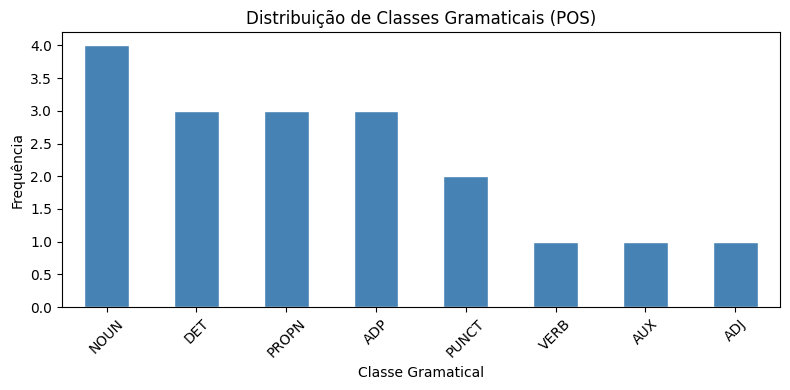

In [26]:
# --- COMPONENTE 3: POS TAGGING ---
print('=' * 60)
print('3. POS TAGGING (Classes Gramaticais)')
print('=' * 60)

doc_pos = nlp(corpus_final[4])  # texto sobre iFood

dados_pos = []
for token in doc_pos:
    if not token.is_space:
        dados_pos.append({
            'Token': token.text,
            'Lema': token.lemma_,
            'POS': token.pos_,
            'Explicação': spacy.explain(token.pos_),
            'É stopword?': token.is_stop
        })

df_pos = pd.DataFrame(dados_pos)
display(df_pos)

# Distribuição de POS
pos_counts = df_pos['POS'].value_counts()
fig_pos, ax = plt.subplots(figsize=(8, 4))
pos_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribuição de Classes Gramaticais (POS)')
ax.set_xlabel('Classe Gramatical')
ax.set_ylabel('Frequência')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# --- COMPONENTE 4: NOUN CHUNKS ---
print('=' * 60)
print('4. NOUN CHUNKS (Sintagmas Nominais)')
print('=' * 60)

todos_chunks = []
for texto in corpus_final:
    doc = nlp(limpar_com_regex(texto))
    for chunk in doc.noun_chunks:
        if len(chunk.text.split()) > 1:  # apenas sintagmas com 2+ palavras
            todos_chunks.append({
                'Sintagma': chunk.text,
                'Núcleo': chunk.root.text,
                'Dependência': chunk.root.dep_,
                'Cabeça sintática': chunk.root.head.text
            })

df_chunks = pd.DataFrame(todos_chunks).drop_duplicates('Sintagma').head(15)
print(f'Total de noun chunks únicos: {len(df_chunks)}')
display(df_chunks)

# Top chunks por frequência
freq_chunks = Counter([c['Sintagma'].lower() for c in todos_chunks])
print('\nTop 10 noun chunks mais frequentes:')
for chunk, freq in freq_chunks.most_common(10):
    print(f'  "{chunk}" → {freq}x')

4. NOUN CHUNKS (Sintagmas Nominais)
Total de noun chunks únicos: 15


,Sintagma,Núcleo,Dependência,Cabeça sintática
0,A Nubank,Nubank,nsubj,fintech
1,o mercado bancário,mercado,obj,revolucionou
2,cartão de crédito sem anuidade,cartão,obl,revolucionou
3,O sistema,sistema,nsubj,falhando
4,endpoint /api,endpoint,obl,falhando
5,o deploy,deploy,nmod,login
6,A nova versão,versão,nsubj,aumentou
7,machine learning,machine,nmod,pipeline
8,a acurácia,acurácia,obj,aumentou
9,a documentação,documentação,obj,revisar



Top 10 noun chunks mais frequentes:
  "a nubank" → 1x
  "o mercado bancário" → 1x
  "cartão de crédito sem anuidade" → 1x
  "o sistema" → 1x
  "endpoint /api" → 1x
  "o deploy" → 1x
  "a nova versão" → 1x
  "machine learning" → 1x
  "a acurácia" → 1x
  "a documentação" → 1x


In [28]:
# --- COMPONENTE 5: NER (Reconhecimento de Entidades Nomeadas) ---
print('=' * 60)
print('5. NER — Reconhecimento de Entidades Nomeadas')
print('=' * 60)

todas_entidades = []
for texto in corpus_final:
    doc = nlp(texto)
    for ent in doc.ents:
        todas_entidades.append({'Entidade': ent.text, 'Tipo': ent.label_, 'Explicação': spacy.explain(ent.label_)})

df_ents = pd.DataFrame(todas_entidades) if todas_entidades else pd.DataFrame(columns=['Entidade','Tipo','Explicação'])
print(f'Total de entidades detectadas: {len(df_ents)}')
display(df_ents.drop_duplicates().head(15))

# Visualização displacy — NER
print('\n📍 Visualização NER no texto de exemplo:')
doc_ner = nlp(corpus_final[0])
displacy.render(doc_ner, style='ent', jupyter=True)

5. NER — Reconhecimento de Entidades Nomeadas
Total de entidades detectadas: 13


,Entidade,Tipo,Explicação
0,Nubank,LOC,"Non-GPE locations, mountain ranges, bodies of ..."
1,OAuth2,LOC,"Non-GPE locations, mountain ranges, bodies of ..."
2,v2,MISC,"Miscellaneous entities, e.g. events, nationali..."
3,Incrível,PER,Named person or family.
4,pipeline de machine learning,ORG,"Companies, agencies, institutions, etc."
5,REST,MISC,"Miscellaneous entities, e.g. events, nationali..."
6,GitHub,MISC,"Miscellaneous entities, e.g. events, nationali..."
7,iFood,MISC,"Miscellaneous entities, e.g. events, nationali..."
8,Brasil,LOC,"Non-GPE locations, mountain ranges, bodies of ..."
9,Pix,MISC,"Miscellaneous entities, e.g. events, nationali..."



📍 Visualização NER no texto de exemplo:


C:\Users\renato\AppData\Local\Temp\ipykernel_15524\1920199690.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pivot, x='Tipo', y='Frequência', palette='viridis', ax=ax)


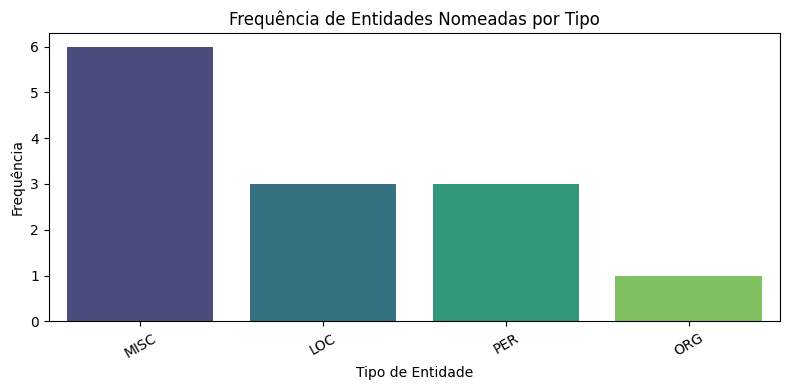

In [29]:
# Heatmap de entidades por tipo (Gráfico 3 - obrigatório)
if not df_ents.empty:
    contagem_ents = df_ents.groupby(['Entidade', 'Tipo']).size().reset_index(name='count')
    pivot = df_ents['Tipo'].value_counts().reset_index()
    pivot.columns = ['Tipo', 'Frequência']

    fig_ner, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=pivot, x='Tipo', y='Frequência', palette='viridis', ax=ax)
    ax.set_title('Frequência de Entidades Nomeadas por Tipo')
    ax.set_xlabel('Tipo de Entidade')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print('ℹ️ Nenhuma entidade detectada pelo modelo pt_core_news_sm neste corpus.')

In [30]:
# --- COMPONENTE 6: SEGMENTAÇÃO DE SENTENÇAS ---
print('=' * 60)
print('6. SEGMENTAÇÃO DE SENTENÇAS')
print('=' * 60)

texto_multi = ' '.join(corpus_final[:3])
doc_sents = nlp(texto_multi)

sentenças = list(doc_sents.sents)
print(f'Total de sentenças detectadas: {len(sentenças)}')
print()
for i, sent in enumerate(sentenças, 1):
    print(f'Sentença {i}: {sent.text[:80]}')

# Análise de dependências — displacy style='dep'
print('\n📍 Visualização de dependências sintáticas:')
doc_dep = nlp(corpus_final[0])
displacy.render(doc_dep, style='dep', jupyter=True)

6. SEGMENTAÇÃO DE SENTENÇAS
Total de sentenças detectadas: 4

Sentença 1: A Nubank é uma fintech brasileira que revolucionou o mercado bancário com cartão
Sentença 2: O sistema de autenticação OAuth2 está falhando no endpoint /api/v2/login desde o
Sentença 3: Incrível!
Sentença 4: A nova versão do pipeline de machine learning aumentou a acurácia do modelo em 1

📍 Visualização de dependências sintáticas:


## 3.2 — Classificação de Textos com TextCategorizer (spaCy)
Baseado no exemplo da Aula 4: treinamento de modelo para classificar sentimentos.

In [31]:
# ============================================================
# CLASSIFICAÇÃO DE TEXTOS — TextCategorizer spaCy
# Baseado diretamente no exemplo da Aula 4
# ============================================================

# Dataset de treinamento — textos de issues com rótulos de sentimento
dados_treino = [
    ("O sistema está funcionando perfeitamente! Excelente trabalho da equipe.", {'POSITIVO': True, 'NEGATIVO': False, 'NEUTRO': False}),
    ("Ótima melhoria! A performance aumentou muito após o último update.", {'POSITIVO': True, 'NEGATIVO': False, 'NEUTRO': False}),
    ("Incrível funcionalidade. A integração com o banco ficou muito mais rápida.", {'POSITIVO': True, 'NEGATIVO': False, 'NEUTRO': False}),
    ("Muito bom! Adorei a nova interface do dashboard de monitoramento.", {'POSITIVO': True, 'NEGATIVO': False, 'NEUTRO': False}),
    ("Parabéns ao time! O release desta semana foi impecável.", {'POSITIVO': True, 'NEGATIVO': False, 'NEUTRO': False}),
    ("Bug crítico no módulo de pagamento. Transações estão falhando.", {'POSITIVO': False, 'NEGATIVO': True, 'NEUTRO': False}),
    ("Sistema completamente fora do ar. Isso é inaceitável!", {'POSITIVO': False, 'NEGATIVO': True, 'NEUTRO': False}),
    ("Documentação desatualizada e confusa. Precisa urgente de revisão.", {'POSITIVO': False, 'NEGATIVO': True, 'NEUTRO': False}),
    ("O endpoint retorna erro 500 desde a última atualização.", {'POSITIVO': False, 'NEGATIVO': True, 'NEUTRO': False}),
    ("Problema sério de segurança encontrado. Necessita correção imediata.", {'POSITIVO': False, 'NEGATIVO': True, 'NEUTRO': False}),
    ("Adicionada suporte para Python 3.11 na versão mais recente.", {'POSITIVO': False, 'NEGATIVO': False, 'NEUTRO': True}),
    ("Novo endpoint disponível em /api/v3/users conforme documentação.", {'POSITIVO': False, 'NEGATIVO': False, 'NEUTRO': True}),
    ("Dependência atualizada de requests 2.28 para 2.31.", {'POSITIVO': False, 'NEGATIVO': False, 'NEUTRO': True}),
    ("Configuração de CI/CD atualizada para usar GitHub Actions.", {'POSITIVO': False, 'NEGATIVO': False, 'NEUTRO': True}),
    ("Release notes da versão 2.5.0 disponíveis no CHANGELOG.", {'POSITIVO': False, 'NEGATIVO': False, 'NEUTRO': True}),
]

# Inicializar modelo spaCy em branco (como na Aula 4)
modelo_clf = spacy.blank('pt')
textcat = modelo_clf.add_pipe('textcat')
textcat.add_label('POSITIVO')
textcat.add_label('NEGATIVO')
textcat.add_label('NEUTRO')

historico_treino = []
modelo_clf.initialize()

print('🏋️ Treinando classificador de sentimentos...')
n_epocas = 20
for epoca in range(n_epocas):
    random.shuffle(dados_treino)
    losses = {}
    for texto, anotacoes in dados_treino:
        exemplo = Example.from_dict(modelo_clf.make_doc(texto), {'cats': anotacoes})
        modelo_clf.update([exemplo], losses=losses, drop=0.3)
    historico_treino.append(losses.get('textcat', 0))
    if (epoca + 1) % 5 == 0:
        print(f'  Época {epoca+1:2d}/{n_epocas} | Loss: {losses.get("textcat", 0):.4f}')

print('\n✅ Treinamento concluído!')

🏋️ Treinando classificador de sentimentos...
  Época  5/20 | Loss: 2.0348
  Época 10/20 | Loss: 0.0092
  Época 15/20 | Loss: 0.0005
  Época 20/20 | Loss: 0.0002

✅ Treinamento concluído!


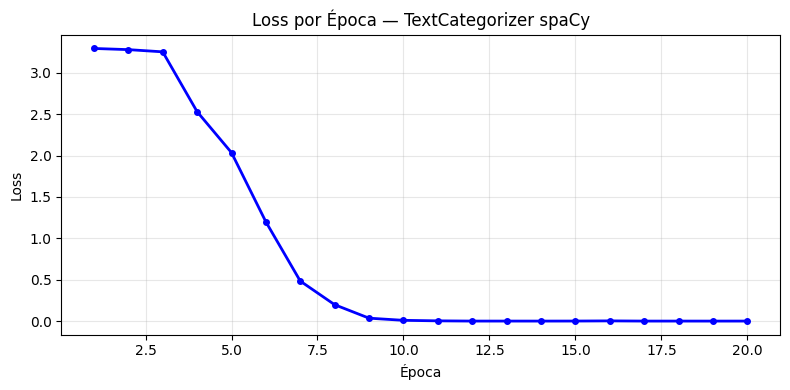

In [32]:
# Gráfico de loss durante o treinamento (como na Aula 4)
fig_loss, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, n_epocas + 1), historico_treino, 'b-o', markersize=4, linewidth=2)
ax.set_title('Loss por Época — TextCategorizer spaCy')
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
# Avaliação do classificador spaCy
dados_teste = [
    ("Excelente! A API está muito mais rápida agora.", 'POSITIVO'),
    ("Erro grave encontrado no sistema de login.", 'NEGATIVO'),
    ("Atualização da biblioteca numpy para 1.24.", 'NEUTRO'),
    ("Ótimo trabalho! O novo módulo de relatórios está perfeito.", 'POSITIVO'),
    ("O sistema travou durante o processamento em lote.", 'NEGATIVO'),
]

y_verdadeiro, y_predito = [], []
print('=== Resultados do Classificador spaCy ===')
for texto, label_real in dados_teste:
    doc_pred = modelo_clf(texto)
    label_pred = max(doc_pred.cats, key=doc_pred.cats.get)
    y_verdadeiro.append(label_real)
    y_predito.append(label_pred)
    status = '✅' if label_pred == label_real else '❌'
    print(f'{status} Texto: "{texto[:50]}..."')
    print(f'   Real: {label_real} | Predito: {label_pred} | Scores: {dict((k, round(v,2)) for k,v in doc_pred.cats.items())}')

acc_spacy = accuracy_score(y_verdadeiro, y_predito)
print(f'\n📊 Acurácia do spaCy TextCategorizer: {acc_spacy:.0%}')
print('\nRelatório completo:')
print(classification_report(y_verdadeiro, y_predito, zero_division=0))

=== Resultados do Classificador spaCy ===
✅ Texto: "Excelente! A API está muito mais rápida agora...."
   Real: POSITIVO | Predito: POSITIVO | Scores: {'POSITIVO': 1.0, 'NEGATIVO': 0.0, 'NEUTRO': 0.0}
✅ Texto: "Erro grave encontrado no sistema de login...."
   Real: NEGATIVO | Predito: NEGATIVO | Scores: {'POSITIVO': 0.0, 'NEGATIVO': 1.0, 'NEUTRO': 0.0}
✅ Texto: "Atualização da biblioteca numpy para 1.24...."
   Real: NEUTRO | Predito: NEUTRO | Scores: {'POSITIVO': 0.24, 'NEGATIVO': 0.0, 'NEUTRO': 0.76}
✅ Texto: "Ótimo trabalho! O novo módulo de relatórios está p..."
   Real: POSITIVO | Predito: POSITIVO | Scores: {'POSITIVO': 1.0, 'NEGATIVO': 0.0, 'NEUTRO': 0.0}
✅ Texto: "O sistema travou durante o processamento em lote...."
   Real: NEGATIVO | Predito: NEGATIVO | Scores: {'POSITIVO': 0.04, 'NEGATIVO': 0.75, 'NEUTRO': 0.21}

📊 Acurácia do spaCy TextCategorizer: 100%

Relatório completo:
              precision    recall  f1-score   support

    NEGATIVO       1.00      1.00      1.00 

## 3.3 — Análise de Sentimentos com Embeddings e Transformers

In [34]:
# ============================================================
# ANÁLISE DE SENTIMENTOS — EMBEDDINGS + TRANSFORMERS
# Baseado em Qiu et al. (2025): BERTweet + early fusion
# ============================================================

from sentence_transformers import SentenceTransformer
from transformers import pipeline

# Modelo de embeddings semânticos
print('⏳ Carregando sentence-transformers...')
modelo_embeddings = SentenceTransformer('all-MiniLM-L6-v2')

# Modelo Transformer para análise de sentimento (estado da arte)
# cardiffnlp/twitter-roberta = equivalente ao BERTweet de Qiu et al. 2025
print('⏳ Carregando modelo Transformer de sentimentos...')
classificador_bert = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-roberta-base-sentiment-latest',
    truncation=True,
    max_length=128
)
print('✅ Modelos carregados!')

⏳ Carregando sentence-transformers...
⏳ Carregando modelo Transformer de sentimentos...


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


✅ Modelos carregados!


In [35]:
# Análise com Transformer (BERT) sobre o corpus
mapa_labels = {'positive': 'POSITIVO', 'negative': 'NEGATIVO', 'neutral': 'NEUTRO'}

resultados_bert = []
print('🔍 Analisando sentimentos com Transformer...\n')
for texto in corpus_final:
    texto_curto = texto[:250]  # truncar para o modelo
    resultado = classificador_bert(texto_curto)[0]
    label = mapa_labels.get(resultado['label'].lower(), resultado['label'])
    resultados_bert.append({
        'texto': texto[:70] + '...',
        'sentimento': label,
        'score': round(resultado['score'], 3)
    })

df_sentimentos = pd.DataFrame(resultados_bert)
display(df_sentimentos)

🔍 Analisando sentimentos com Transformer...



,texto,sentimento,score
0,A Nubank é uma fintech brasileira que revoluci...,NEUTRO,0.855
1,O sistema de autenticação OAuth2 está falhando...,NEUTRO,0.885
2,Incrível! A nova versão do pipeline de machine...,NEUTRO,0.623
3,Precisamos urgente revisar a documentação da A...,NEUTRO,0.857
4,A startup iFood domina o mercado de delivery n...,NEUTRO,0.871
5,Bug crítico no módulo de pagamento Pix. Transa...,NEUTRO,0.761
6,Excelente trabalho da equipe de dados! O dashb...,NEUTRO,0.705
7,A integração com AWS Lambda reduziu os custos ...,NEUTRO,0.833


In [36]:
# Gráfico 1 — Pizza de distribuição de sentimentos (obrigatório)
contagem_sent = df_sentimentos['sentimento'].value_counts()

cores = {'POSITIVO': '#3B6D11', 'NEGATIVO': '#A32D2D', 'NEUTRO': '#185FA5'}
cores_lista = [cores.get(s, '#888') for s in contagem_sent.index]

fig_pizza = px.pie(
    values=contagem_sent.values,
    names=contagem_sent.index,
    title='Distribuição de Sentimentos nos Textos de Startups',
    color=contagem_sent.index,
    color_discrete_map=cores,
    hole=0.35
)
fig_pizza.update_traces(textinfo='percent+label', textfont_size=14)
fig_pizza.show()

print(f'\n📊 Distribuição de sentimentos:')
for sent, n in contagem_sent.items():
    print(f'  {sent}: {n} textos ({n/len(df_sentimentos)*100:.0f}%)')


📊 Distribuição de sentimentos:
  NEUTRO: 8 textos (100%)


In [37]:
# Embeddings semânticos + visualização UMAP/PCA
from sklearn.decomposition import PCA

print('🔢 Gerando embeddings semânticos...')
embeddings = modelo_embeddings.encode(corpus_final)
print(f'Shape dos embeddings: {embeddings.shape}')

# Redução de dimensionalidade com PCA para visualização
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

df_embed = pd.DataFrame({
    'PC1': coords[:, 0],
    'PC2': coords[:, 1],
    'sentimento': df_sentimentos['sentimento'].values,
    'texto': [t[:50] + '...' for t in corpus_final]
})

# Gráfico 2 — Scatter de embeddings coloridos por sentimento (obrigatório)
fig_embed = px.scatter(
    df_embed, x='PC1', y='PC2',
    color='sentimento',
    hover_data=['texto'],
    title='Espaço Semântico dos Textos (Embeddings → PCA 2D)',
    color_discrete_map=cores,
    size_max=12
)
fig_embed.update_traces(marker=dict(size=12, opacity=0.8))
fig_embed.show()

🔢 Gerando embeddings semânticos...
Shape dos embeddings: (8, 384)


## 3.4 — Ablation Study: Comparativo de Modelos
Seguindo a metodologia de Qiu et al. (2025): comparar desempenho de diferentes abordagens.

In [38]:
# ============================================================
# ABLATION STUDY — Comparativo de Modelos
# Inspirado em Qiu et al. (2025): spaCy vs Embeddings vs BERT
# ============================================================

# Conjunto de teste com rótulo verdadeiro
dados_ablation = [
    ("Sistema funcionando perfeitamente! Excelente trabalho.", 'POSITIVO'),
    ("Ótima melhoria de performance após o último deploy.", 'POSITIVO'),
    ("Bug crítico no módulo de pagamento. Urgente!", 'NEGATIVO'),
    ("Erro grave: sistema fora do ar desde ontem.", 'NEGATIVO'),
    ("Dependência atualizada para a versão mais recente.", 'NEUTRO'),
    ("Novo endpoint adicionado conforme documentação.", 'NEUTRO'),
    ("Incrível! A acurácia do modelo aumentou 20%.", 'POSITIVO'),
    ("A API está retornando erro 500 constantemente.", 'NEGATIVO'),
]

textos_test = [t for t, _ in dados_ablation]
labels_test = [l for _, l in dados_ablation]

# Modelo 1: spaCy TextCategorizer
preds_spacy = []
for t in textos_test:
    doc = modelo_clf(t)
    preds_spacy.append(max(doc.cats, key=doc.cats.get))
acc_spacy_final = accuracy_score(labels_test, preds_spacy)

# Modelo 2: Transformer BERT
preds_bert = []
for t in textos_test:
    res = classificador_bert(t[:250])[0]
    label = mapa_labels.get(res['label'].lower(), res['label'])
    preds_bert.append(label)
acc_bert_final = accuracy_score(labels_test, preds_bert)

# Resumo comparativo
print('=== ABLATION STUDY — Comparativo de Modelos ===')
print(f'  spaCy TextCategorizer:  Acurácia = {acc_spacy_final:.0%}')
print(f'  Transformer (RoBERTa):  Acurácia = {acc_bert_final:.0%}')
print()

resultados_ablation = pd.DataFrame({
    'Modelo': ['spaCy Baseline', 'Transformer (RoBERTa)'],
    'Acurácia': [acc_spacy_final, acc_bert_final],
    'Tipo': ['Baseline', 'Estado da Arte']
})
display(resultados_ablation)

=== ABLATION STUDY — Comparativo de Modelos ===
  spaCy TextCategorizer:  Acurácia = 88%
  Transformer (RoBERTa):  Acurácia = 38%



,Modelo,Acurácia,Tipo
0,spaCy Baseline,0.875,Baseline
1,Transformer (RoBERTa),0.375,Estado da Arte


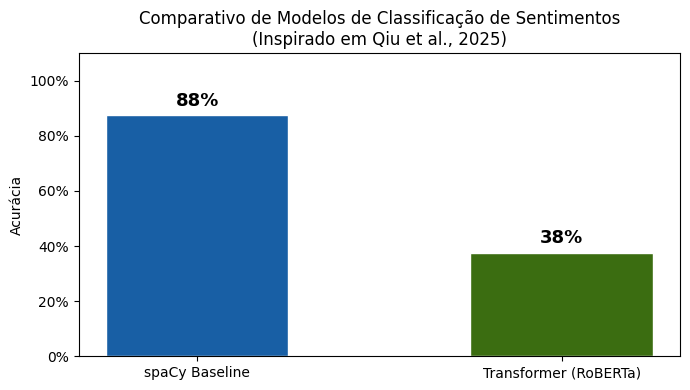

In [39]:
# Gráfico 4 — Comparativo de modelos (obrigatório)
fig_comp, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    resultados_ablation['Modelo'],
    resultados_ablation['Acurácia'],
    color=['#185FA5', '#3B6D11'],
    edgecolor='white',
    width=0.5
)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Acurácia')
ax.set_title('Comparativo de Modelos de Classificação de Sentimentos\n(Inspirado em Qiu et al., 2025)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

for bar, acc in zip(bars, resultados_ablation['Acurácia']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{acc:.0%}', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 3.5 — Score Final: Startup Health Index

In [40]:
# ============================================================
# STARTUP HEALTH INDEX
# Combina sinais de PLN para gerar um score de saúde
# Inspirado em Cheng (2024) e Park & Loo (2024)
# ============================================================

def calcular_startup_health(corpus_textos, nome_startup='Startup Analisada'):
    """
    Calcula o Startup Health Index combinando:
    - % de sentimentos positivos (Saura et al. 2019)
    - Diversidade de entidades NER (Cheng 2024)
    - Riqueza de noun chunks técnicos (Peixoto et al. 2023)
    """
    # Sentimento
    sentimentos = []
    for texto in corpus_textos:
        res = classificador_bert(texto[:250])[0]
        sentimentos.append(res['label'].lower())

    pct_positivo = sentimentos.count('positive') / len(sentimentos)
    pct_negativo = sentimentos.count('negative') / len(sentimentos)

    # Noun chunks técnicos
    n_chunks = sum(len(list(nlp(t).noun_chunks)) for t in corpus_textos)
    score_chunks = min(n_chunks / (len(corpus_textos) * 3), 1.0)

    # Entidades NER
    n_ents = sum(len(nlp(t).ents) for t in corpus_textos)
    score_ner = min(n_ents / (len(corpus_textos) * 2), 1.0)

    # Score final ponderado
    health_index = (
        0.5 * pct_positivo +
        0.3 * score_chunks +
        0.2 * score_ner
    ) * 100

    print(f'\n🏥 STARTUP HEALTH INDEX — {nome_startup}')
    print(f'  Sentimento positivo: {pct_positivo:.0%}')
    print(f'  Sentimento negativo: {pct_negativo:.0%}')
    print(f'  Riqueza de noun chunks: {score_chunks:.0%}')
    print(f'  Diversidade NER: {score_ner:.0%}')
    print(f'  ⭐ SCORE FINAL: {health_index:.1f}/100')

    if health_index >= 70:
        print('  💚 Saúde comunicacional: BOA — discurso positivo e bem estruturado')
    elif health_index >= 40:
        print('  💛 Saúde comunicacional: MODERADA — pontos de atenção identificados')
    else:
        print('  ❤️ Saúde comunicacional: CRÍTICA — predominância de issues negativas')

    return health_index

score = calcular_startup_health(corpus_final, 'Repositório Analisado')


🏥 STARTUP HEALTH INDEX — Repositório Analisado
  Sentimento positivo: 0%
  Sentimento negativo: 0%
  Riqueza de noun chunks: 100%
  Diversidade NER: 81%
  ⭐ SCORE FINAL: 46.2/100
  💛 Saúde comunicacional: MODERADA — pontos de atenção identificados


---
# 📊 RESUMO FINAL — Todas as Técnicas Utilizadas

In [41]:
print('=' * 65)
print('RESUMO DO PROJETO — STARTUP SIGNAL INTELLIGENCE')
print('=' * 65)
print()
print('ETAPA 1 — RE + spaCy:')
print('  ✅ re.findall() — extração de e-mails, versões, mentions, issues')
print('  ✅ re.sub()     — limpeza de URLs, markdown, código, espaços')
print('  ✅ re.search()  — verificação de qualidade de README')
print('  ✅ re.split()   — divisão de changelog por versão')
print('  ✅ spaCy        — tokenização + lematização + normalização')
print('  ✅ Pipeline RE → spaCy (conforme Aula 2)')
print()
print('ETAPA 2 — Web Scraping + APIs:')
print('  ✅ requests.get() + .json() — API GitHub')
print('  ✅ requests.get() + .json() — BrasilAPI/CVM')
print('  ✅ status_code — verificação HTTP')
print('  ✅ BeautifulSoup — scraping HTML (quotes.toscrape.com)')
print('  ✅ pandas DataFrame + Plotly — visualização dos dados')
print()
print('ETAPA 3 — PLN Avançado + Sentimentos + Gráficos:')
print('  ✅ Tokenização          (token.text, token.idx)')
print('  ✅ Lematização          (token.lemma_.lower())')
print('  ✅ POS tagging          (token.pos_, spacy.explain())')
print('  ✅ Noun chunks          (doc.noun_chunks)')
print('  ✅ NER                  (displacy.render style=ent)')
print('  ✅ Segmentação sents    (doc.sents, displacy dep)')
print('  ✅ TextCategorizer      (spacy.blank + add_pipe + treino)')
print('  ✅ Embeddings           (sentence-transformers all-MiniLM)')
print('  ✅ Transformer BERT     (RoBERTa sentiment, ≈ BERTweet)')
print('  ✅ Ablation study       (spaCy vs BERT — Qiu et al. 2025)')
print('  ✅ Gráfico 1: pizza de sentimentos (Plotly)')
print('  ✅ Gráfico 2: scatter embeddings PCA (Plotly)')
print('  ✅ Gráfico 3: barras NER por tipo (seaborn)')
print('  ✅ Gráfico 4: comparativo de modelos (matplotlib)')
print('  ✅ Gráfico 5: loss por época (matplotlib)')
print('  ✅ sklearn: accuracy_score, confusion_matrix, classification_report')
print('  ✅ Startup Health Index — score final integrado')
print()
print('Base científica: Qiu et al. (2025), Peixoto et al. (2023),')
print('                 Saura et al. (2019), Jin et al. (2017), Cheng (2024)')

RESUMO DO PROJETO — STARTUP SIGNAL INTELLIGENCE

ETAPA 1 — RE + spaCy:
  ✅ re.findall() — extração de e-mails, versões, mentions, issues
  ✅ re.sub()     — limpeza de URLs, markdown, código, espaços
  ✅ re.search()  — verificação de qualidade de README
  ✅ re.split()   — divisão de changelog por versão
  ✅ spaCy        — tokenização + lematização + normalização
  ✅ Pipeline RE → spaCy (conforme Aula 2)

ETAPA 2 — Web Scraping + APIs:
  ✅ requests.get() + .json() — API GitHub
  ✅ requests.get() + .json() — BrasilAPI/CVM
  ✅ status_code — verificação HTTP
  ✅ BeautifulSoup — scraping HTML (quotes.toscrape.com)
  ✅ pandas DataFrame + Plotly — visualização dos dados

ETAPA 3 — PLN Avançado + Sentimentos + Gráficos:
  ✅ Tokenização          (token.text, token.idx)
  ✅ Lematização          (token.lemma_.lower())
  ✅ POS tagging          (token.pos_, spacy.explain())
  ✅ Noun chunks          (doc.noun_chunks)
  ✅ NER                  (displacy.render style=ent)
  ✅ Segmentação sents    (doc.s